In [1]:
import torch
import torch.nn as nn
from torch.distributions import MultivariateNormal
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import optparse
import pickle

import matplotlib.pyplot as plt

import sac.memory as mem
from sac.feedforward import Feedforward
# import SAC
from sac.DDPG import DDPGAgent
from sac.utils import *

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(1)

In [2]:
env_name = "Pendulum-v1"
env = gym.make(env_name)

In [3]:
render = False
log_interval = 20           # print avg reward in the interval
new_episodes = 1000 # max training episodes
max_timesteps = 2000   
save_interval = 500

In [40]:
params = SB3_PARAMS
params["fit_steps"] = 200

In [41]:
random_seed = 0

In [42]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [43]:
hidden_sizes = [256, 256]
sac = from_dict(env=env, hidden_sizes=hidden_sizes, **params)

In [44]:
agent = sac
agent_name = "SAC"

In [45]:
filepath = f"./results2/{agent_name}-{env_name}-{random_seed}"

In [46]:
warmup_agent(agent, env, 256, max_timesteps)

In [47]:
losses = []
rewards = []
lengths = []
i_episode = 0

In [48]:
losses, rewards, lengths, i_episode = train_agent(agent, env, i_episode, new_episodes, max_timesteps, filepath, losses, rewards, lengths, log_interval=1, save_interval=20, train_interval=200)

Episode 1 	 avg length: 200 	 reward: -1445.2402856241567
Episode 2 	 avg length: 200 	 reward: -1349.7761669003796
Episode 3 	 avg length: 200 	 reward: -1254.0075304561267
Episode 4 	 avg length: 200 	 reward: -1324.0177132187432
Episode 5 	 avg length: 200 	 reward: -1063.533239280518
Episode 6 	 avg length: 200 	 reward: -1484.9881175162989
Episode 7 	 avg length: 200 	 reward: -1509.845498172117
Episode 8 	 avg length: 200 	 reward: -826.3138683720776
Episode 9 	 avg length: 200 	 reward: -1135.8920731074384
Episode 10 	 avg length: 200 	 reward: -1413.3392209426934
Episode 11 	 avg length: 200 	 reward: -1415.4196474707085
Episode 12 	 avg length: 200 	 reward: -601.4130146168073
Episode 13 	 avg length: 200 	 reward: -649.2869505552873
Episode 14 	 avg length: 200 	 reward: -518.2838558898482
Episode 15 	 avg length: 200 	 reward: -508.85300644477564
Episode 16 	 avg length: 200 	 reward: -491.8417469200821
Episode 17 	 avg length: 200 	 reward: -119.88316831441654
Episode 18 	 

KeyboardInterrupt: 

In [13]:
rewards, lengths, losses = load_stats(filepath) 

In [49]:
from sac.plots import *

In [50]:
plot_path = "plots2"

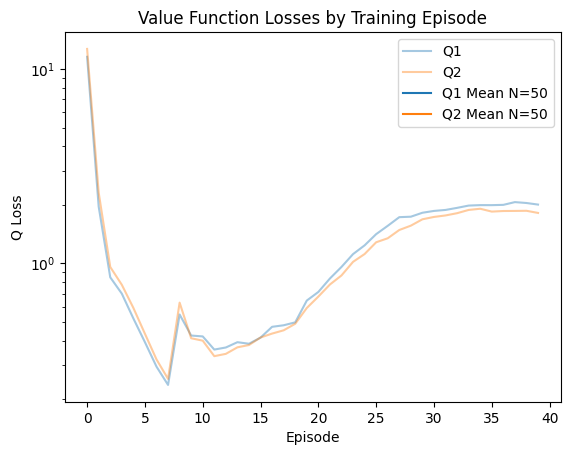

In [52]:
q_losses = np.asarray(losses)[:,:2]
plot_q(q_losses, plot_path)

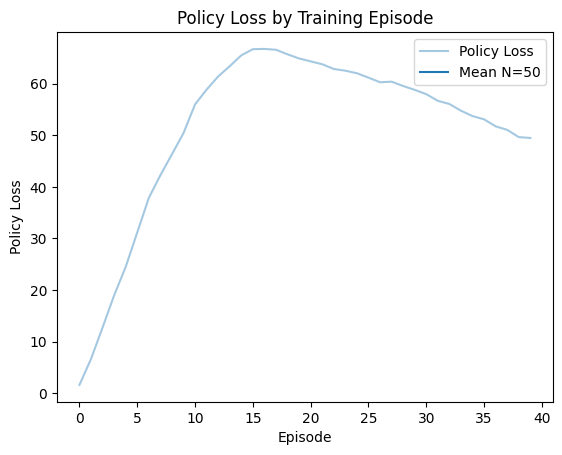

In [53]:
policy_loss = np.asarray(losses)[:,2]
plot_policy_loss(policy_loss, plot_path)

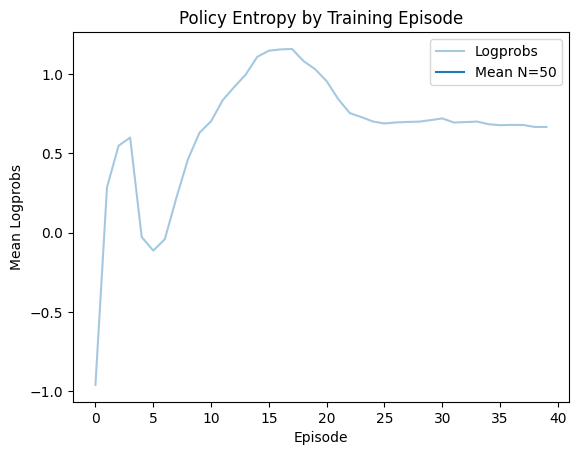

In [54]:
logprobs = np.asarray(losses)[:,-1]
plot_entropy(logprobs, plot_path)

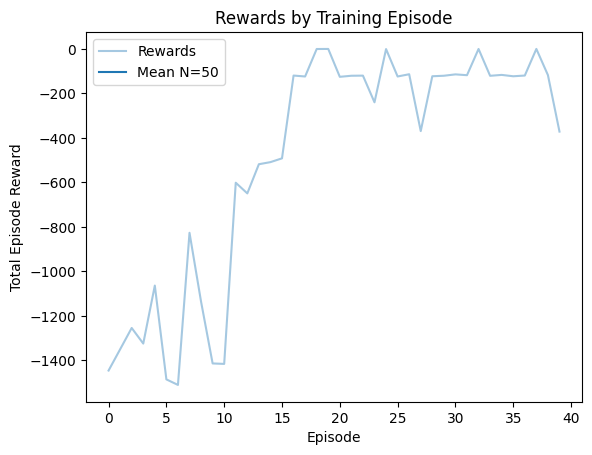

In [55]:
plot_rewards(rewards, plot_path)